In [1]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import os
import sys
SRC_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(SRC_PATH)

from src.common import utils
from src.common.stopwords import STOPWORDS
from src.movies.transformer import TextPreprocessor
from src.common.visualization import plot_class_wordclouds

%load_ext autoreload
%autoreload 2

In [2]:
fname = "../Dataset/movies1000/"
texts, classes = utils.load_movies(fname)
classes = np.array(classes)

In [3]:
text_preprocessor = TextPreprocessor(stem=False, lemmatize=True, stopwords=STOPWORDS["english"]).fit(texts)
texts_cleaned = text_preprocessor.transform(texts)

In [ ]:
vectorizer = TfidfVectorizer(min_df=5, max_df=0.60, ngram_range=(1, 2))
vectors = vectorizer.fit_transform(texts_cleaned)
vocab = vectorizer.get_feature_names_out()
print("Vocab length:", len(vocab))
sns.histplot(vectors.data)

Vocab length: 21832


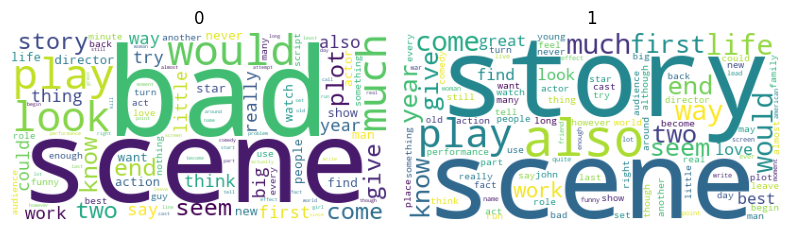

In [5]:
vectorizer=CountVectorizer(vocabulary=vocab, ngram_range=(1, 2))
plot_class_wordclouds(texts_cleaned, classes, vectorizer)

# Models

In [4]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(texts_cleaned, classes, random_state=42)

In [7]:
pipeline = Pipeline([
    #("preprocess", TextPreprocessor(stem=False, lemmatize=True, lang="english", stopwords=STOPWORDS["english"])),
    ("vectorizer", CountVectorizer(analyzer="char", ngram_range=(1, 1))),
    ("classifier", MultinomialNB()) # supposed to work better with count vectorizer
])

# # Cross validation
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Scores : [0.57333333 0.55666667 0.70666667 0.59       0.66      ], mean score : 0.6173333333333333
0.62
              precision    recall  f1-score   support

           0       0.64      0.61      0.62       257
           1       0.60      0.63      0.62       243

    accuracy                           0.62       500
   macro avg       0.62      0.62      0.62       500
weighted avg       0.62      0.62      0.62       500



In [ ]:
pipeline = Pipeline([
    #("preprocess", TextPreprocessor(stem=False, lemmatize=True, lang="english", stopwords=STOPWORDS["english"])),
    ("vectorizer", CountVectorizer(analyzer="char_wb", ngram_range=(3, 5))),
    ("classifier", MultinomialNB()) # supposed to work better with count vectorizer
])

# # Cross validation
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

KeyboardInterrupt: 

In [7]:
pipeline = Pipeline([
    #("preprocess", TextPreprocessor(stem=False, lemmatize=True, lang="english", stopwords=STOPWORDS["english"])),
    ("vectorizer", TfidfVectorizer(min_df=5, max_df=0.60, max_features=5000)),
    ("classifier", MultinomialNB()) # supposed to work better with count vectorizer
])

# # Cross validation
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Scores : [0.83333333 0.84666667 0.81333333 0.73       0.82333333], mean score : 0.8093333333333333
0.828
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       257
           1       0.83      0.81      0.82       243

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



In [8]:
pipeline = Pipeline([
    #("preprocess", TextPreprocessor(stem=False, lemmatize=True, lang="english", stopwords=STOPWORDS["english"])),
    ("vectorizer", TfidfVectorizer(min_df=5, max_df=0.60, max_features=5000)),
    ("classifier", LogisticRegression())
])

# Cross validation
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Scores : [0.83       0.85       0.82666667 0.77       0.84333333], mean score : 0.8240000000000001
0.854
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       257
           1       0.83      0.88      0.85       243

    accuracy                           0.85       500
   macro avg       0.85      0.85      0.85       500
weighted avg       0.86      0.85      0.85       500



In [9]:
pipeline = Pipeline([
    #("preprocess", TextPreprocessor(stem=False, lemmatize=True, lang="english", stopwords=STOPWORDS["english"])),
    ("vectorizer", TfidfVectorizer(min_df=5, max_df=0.60, max_features=5000, ngram_range=(1, 2))),
    ("classifier", LogisticRegression())
])

# # Cross validation
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Scores : [0.83333333 0.85       0.82666667 0.76       0.84666667], mean score : 0.8233333333333333
0.864
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       257
           1       0.84      0.89      0.86       243

    accuracy                           0.86       500
   macro avg       0.86      0.86      0.86       500
weighted avg       0.87      0.86      0.86       500



In [10]:
pipeline = Pipeline([
    #("preprocess", TextPreprocessor(stem=False, lemmatize=True, lang="english", stopwords=STOPWORDS["english"])),
    ("vectorizer", CountVectorizer(min_df=5, max_df=0.60, max_features=5000)),
    ("classifier", MultinomialNB())
])

# Cross validation
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Scores : [0.84666667 0.82333333 0.82666667 0.73333333 0.84666667], mean score : 0.8153333333333332
0.83
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       257
           1       0.83      0.81      0.82       243

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



In [11]:
pipeline = Pipeline([
    # ("preprocess", TextPreprocessor(stem=False, lemmatize=True, lang="english", stopwords=STOPWORDS["english"])),
    ("vectorizer", CountVectorizer(min_df=5, max_df=0.80, max_features=5000, ngram_range=(1, 2))),
    ("classifier", MultinomialNB())
])

# Cross validation
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Scores : [0.83       0.82333333 0.82666667 0.74       0.84333333], mean score : 0.8126666666666666
0.816
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       257
           1       0.83      0.78      0.80       243

    accuracy                           0.82       500
   macro avg       0.82      0.81      0.82       500
weighted avg       0.82      0.82      0.82       500

